# CE49X: Introduction to Computational Thinking and Data Science for Civil Engineers
## Week 1 — Theory: The Data Science Lifecycle

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

*Companion notebook to Week 1 lecture — designed for in-class discussion*

---

## Table of Contents

1. [The Question Comes First](#1.-The-Question-Comes-First)
2. [Data Collection & Quality](#2.-Data-Collection-&-Quality)
3. [Exploratory Data Analysis (EDA)](#3.-Exploratory-Data-Analysis-(EDA))
4. [Feature Engineering](#4.-Feature-Engineering)
5. [Modeling](#5.-Modeling)
6. [Evaluation & Communication](#6.-Evaluation-&-Communication)
7. [Reflection](#7.-Reflection)

---
## 1. The Question Comes First

**Scenario:** A construction site has **200 concrete cylinder test results**. Each sample was tested at 7 days and again at 28 days after casting. The site engineer asks:

> *"Can we predict 28-day compressive strength from 7-day tests?"*

If the answer is yes, the construction team could make earlier decisions about concrete quality — potentially saving weeks of waiting time and avoiding costly rework.

Let's walk through the **entire data science lifecycle** using this real-world civil engineering problem.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

# Simulated concrete cylinder test data
n = 200
cement_content = np.random.uniform(280, 400, n)  # kg/m³
water_cement = np.random.uniform(0.35, 0.60, n)
age_7d_strength = 10 + 0.05 * cement_content - 15 * water_cement + np.random.normal(0, 2, n)
age_28d_strength = 1.3 * age_7d_strength + 5 + np.random.normal(0, 3, n)

df = pd.DataFrame({
    'sample_id': [f'C{i+1:03d}' for i in range(n)],
    'cement_kg_m3': np.round(cement_content, 1),
    'water_cement_ratio': np.round(water_cement, 3),
    'strength_7d_MPa': np.round(age_7d_strength, 1),
    'strength_28d_MPa': np.round(age_28d_strength, 1)
})

# Inject real-world data quality issues
df.loc[15, 'strength_28d_MPa'] = 900.0  # Typo: 900 instead of 30
df.loc[42, 'strength_7d_MPa'] = np.nan  # Missing value
df.loc[87, 'strength_7d_MPa'] = np.nan
df.loc[120, 'strength_28d_MPa'] = np.nan
df.loc[55, 'cement_kg_m3'] = -320  # Negative value error
df = pd.concat([df, df.iloc[[10, 10, 73]]], ignore_index=True)  # Duplicate rows

print(f"Dataset: {len(df)} rows × {df.shape[1]} columns")
df.head(10)

Dataset: 203 rows × 5 columns


,sample_id,cement_kg_m3,water_cement_ratio,strength_7d_MPa,strength_28d_MPa
0,C001,324.9,0.511,21.2,30.8
1,C002,394.1,0.371,24.2,38.7
2,C003,367.8,0.390,23.9,37.6
3,C004,351.8,0.575,18.4,25.9
4,C005,298.7,0.502,18.1,28.8
5,C006,298.7,0.352,19.4,32.5
6,C007,287.0,0.375,18.9,24.6
7,C008,383.9,0.516,22.6,36.1
8,C009,352.1,0.351,20.7,29.9
9,C010,365.0,0.390,26.6,41.3


> **[DISCUSS] Look at the data above.**
> - What columns do we have?
> - What would you need to know before building a model?
> - Can you spot any problems just from the first 10 rows?

**Answers:**

- **Columns:** We have `sample_id` (label), `cement_kg_m3` (mix design input), `water_cement_ratio` (mix design input), `strength_7d_MPa` (early-age response), and `strength_28d_MPa` (our prediction target).

- **What you'd need to know before modeling:**
  - Are these all from the same concrete mix, or different mixes? (Different mixes — the cement content and W/C ratio vary.)
  - How were the cylinders tested? (Standard ASTM C39 compression test, presumably.)
  - Were they all cured under the same conditions? (We don't have curing data, which is a limitation.)
  - What is the required design strength? (This determines the "pass/fail" threshold.)

- **Problems visible in the first 10 rows:** The first 10 rows may look fine at a glance — that's the danger. The real issues (outliers, missing values, duplicates, negative values) are hidden deeper in the dataset. This is why we **never** rely on visual inspection of a few rows alone — we need summary statistics and systematic checks. We'll see those in the next step.

> **Key Insight: A data science project starts with a question, not with code.**
> The engineer's question — "Can we predict 28-day strength from 7-day tests?" — drives every decision that follows.

### The CRISP-DM Framework

**CRISP-DM** stands for **CR**oss-**I**ndustry **S**tandard **P**rocess for **D**ata **M**ining. It was developed in the late 1990s by a consortium of companies (including SPSS, Teradata, and Daimler-Benz) and published in 1999. Despite being over 25 years old, it remains the most widely used methodology for structuring data science projects — surveys consistently show that a majority of practitioners still follow some version of it.

The framework defines **six phases**, arranged in a cycle:

```
      ┌──────────────────────────────────┐
      │                                  │
      ▼                                  │
  Business          Data          Data   │
  Understanding → Understanding → Preparation
                                    │    │
                                    ▼    │
  Deployment  ←  Evaluation  ←  Modeling │
      │                                  │
      └──────────────────────────────────┘
```

#### The Six Phases

| Phase | Goal | Civil Engineering Example |
|---|---|---|
| **1. Business Understanding** | Define the problem and success criteria. What decision will this analysis support? | "We need to know 28-day strength earlier to avoid delays. A prediction within ±3 MPa would let us make go/no-go decisions at 7 days." |
| **2. Data Understanding** | Explore and profile the available data. What do we have? Is it trustworthy? | Inspect the 200 cylinder test records — check for missing values, outliers, duplicates, and whether the data covers the range of mixes used on site. |
| **3. Data Preparation** | Clean, transform, and engineer features. Get the data into a form the model can use. | Remove the 900 MPa typo, handle missing values, create derived features like total water content or strength gain ratio. |
| **4. Modeling** | Select and train one or more models. | Fit a linear regression of 28-day strength on 7-day strength; compare with a model that includes engineered features. |
| **5. Evaluation** | Assess whether the model meets the business criteria defined in Phase 1 — not just statistical metrics. | R² = 0.90 and MAE = 2.5 MPa — is that good enough for quality control decisions? What about borderline cases near the 30 MPa threshold? |
| **6. Deployment** | Put the model into practice and communicate results to stakeholders. | Deliver a simple tool or spreadsheet that site engineers can use: enter 7-day strength, get a 28-day prediction with a confidence interval. Train the team on when to trust it and when not to. |

#### Why Iteration Matters

The arrows in the diagram go **both forward and backward**. This is not a conveyor belt — you will frequently loop back:

- During **Data Understanding**, you may realize the original question was too vague → go back to **Business Understanding** to refine it.
- During **Modeling**, you may discover the data needs more cleaning → go back to **Data Preparation**.
- During **Evaluation**, you may find the model fails on a critical case → go back to **Feature Engineering** or even **Data Collection**.

In practice, most projects cycle through these phases **multiple times** before reaching deployment. Experienced data scientists budget for this — they don't expect to get it right on the first pass.

#### Why CRISP-DM and Not Something Else?

Other frameworks exist — **KDD Process** (1996, more academic), **SEMMA** (SAS proprietary), **TDSP** (Microsoft's Team Data Science Process) — but CRISP-DM has endured because:
1. It is **vendor-neutral** and **industry-agnostic** — it works for civil engineering just as well as for marketing or finance.
2. It explicitly includes **Business Understanding** and **Deployment** — phases that purely technical frameworks often ignore, but that determine whether a project actually creates value.
3. It emphasizes **iteration**, which matches how real projects unfold.

> **[DISCUSS] Think about a civil engineering project you've encountered (or can imagine). Which CRISP-DM phase do you think is most likely to be skipped or rushed? What could go wrong if it is?**

**Answer:**

The two most commonly skipped phases — and the most costly to skip:

- **Business Understanding** is often rushed because teams are eager to start coding. But if you don't define *what success looks like* before you begin, you end up with a technically impressive model that nobody uses. Example: a team builds a sophisticated bridge deterioration model, but the maintenance department needed a simple ranking of which bridges to inspect first — not a continuous prediction. The model answered the wrong question.

- **Deployment** is frequently treated as an afterthought. A model sitting in a Jupyter notebook on a researcher's laptop creates zero value. In civil engineering, this means: Can the site engineer actually *use* this prediction? Is it in a format they understand? Is there a process for updating the model when new data arrives? Many excellent analyses die here because nobody planned for how the results would be integrated into actual decision-making.

- **Data Preparation** is the phase people *want* to skip (it's tedious), but rarely do in practice — because the data forces you to deal with it. As we saw: one typo (900 MPa) can ruin an entire model.

---
## 2. Data Collection & Quality

Before doing anything fancy, we need to **understand** and **trust** our data. This stage is often called *data profiling* or *data auditing*.

In [25]:
# [TOGETHER] Run these inspection commands — what do they reveal?
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Shape: {df.shape} ===")
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Basic Statistics ===")
df.describe()

=== Data Types ===
sample_id              object
cement_kg_m3          float64
water_cement_ratio    float64
strength_7d_MPa       float64
strength_28d_MPa      float64
dtype: object

=== Shape: (203, 5) ===

=== Missing Values ===
sample_id             0
cement_kg_m3          0
water_cement_ratio    0
strength_7d_MPa       2
strength_28d_MPa      1
dtype: int64

=== Basic Statistics ===


,cement_kg_m3,water_cement_ratio,strength_7d_MPa,strength_28d_MPa
count,203.000000,203.000000,201.000000,202.000000
mean,334.229557,0.476719,19.746269,34.767327
std,58.203954,0.073093,2.965990,61.385816
min,-320.000000,0.351000,13.100000,18.000000
25%,306.950000,0.417000,17.700000,27.025000
50%,338.700000,0.486000,20.100000,30.200000
75%,369.250000,0.536000,22.000000,33.600000
max,398.400000,0.598000,26.600000,900.000000


> **[DISCUSS] What did you notice?**
> - `describe()` shows max `strength_28d_MPa` = 900 MPa. Concrete maxes out around 100 MPa. That's a data entry error.
> - There are missing values in strength columns.
> - We have 203 rows when we expected 200 — duplicates?
> - A negative cement content value? That's physically impossible.

> **Key Insight: Garbage In, Garbage Out**
> No model can overcome bad data. Data quality determines model quality.

In [26]:
from sklearn.linear_model import LinearRegression

# Model on dirty data
X_dirty = df[['strength_7d_MPa']].dropna()
y_dirty = df.loc[X_dirty.index, 'strength_28d_MPa'].values
X_dirty = X_dirty.values
mask = ~np.isnan(y_dirty)
X_dirty, y_dirty = X_dirty[mask], y_dirty[mask]

model_dirty = LinearRegression().fit(X_dirty, y_dirty)

# Clean the data
df_clean = df.copy()
df_clean = df_clean.drop_duplicates(subset='sample_id')
df_clean = df_clean[df_clean['strength_28d_MPa'] < 200]  # Remove 900 MPa outlier
df_clean = df_clean[df_clean['cement_kg_m3'] > 0]  # Remove negative values
df_clean = df_clean.dropna(subset=['strength_7d_MPa', 'strength_28d_MPa'])

X_clean = df_clean[['strength_7d_MPa']].values
y_clean = df_clean['strength_28d_MPa'].values
model_clean = LinearRegression().fit(X_clean, y_clean)

# Compare predictions
test_point = np.array([[20.0]])
print(f"Dirty model predicts: {model_dirty.predict(test_point)[0]:.1f} MPa for 7-day strength of 20 MPa")
print(f"Clean model predicts: {model_clean.predict(test_point)[0]:.1f} MPa for 7-day strength of 20 MPa")
print(f"\nDirty model R²: {model_dirty.score(X_dirty, y_dirty):.3f}")
print(f"Clean model R²: {model_clean.score(X_clean, y_clean):.3f}")

Dirty model predicts: 35.3 MPa for 7-day strength of 20 MPa
Clean model predicts: 30.9 MPa for 7-day strength of 20 MPa

Dirty model R²: 0.006
Clean model R²: 0.620


The dirty model's R² is much lower, and its predictions are unreliable. **One outlier (900 MPa) distorted the entire regression line.**

> **Key Insight: Data Provenance**
> Always ask: *Where did this data come from? Who collected it? What instruments were used? Can we trust it?*
> In our case, the 900 MPa value was likely a data entry error (perhaps 30.0 mistyped as 900).

In [ ]:
print(f"Original dataset:  {len(df)} rows")
print(f"After dedup:       {len(df.drop_duplicates(subset='sample_id'))} rows")
print(f"After outlier fix: removed 1 row (900 MPa)")
print(f"After neg fix:     removed 1 row (negative cement)")
print(f"After dropna:      {len(df_clean)} rows")
print(f"\nClean dataset ready for analysis: {len(df_clean)} rows × {df_clean.shape[1]} columns")

---
## 3. Exploratory Data Analysis (EDA)

EDA is the **detective work** of data science. Before we build any model, we need to *see* our data — its distributions, relationships, and anomalies.

> **Definition: Exploratory Data Analysis (EDA)**
> A systematic approach to understanding the main characteristics of a dataset, primarily through visualization and summary statistics, before formal modeling begins.

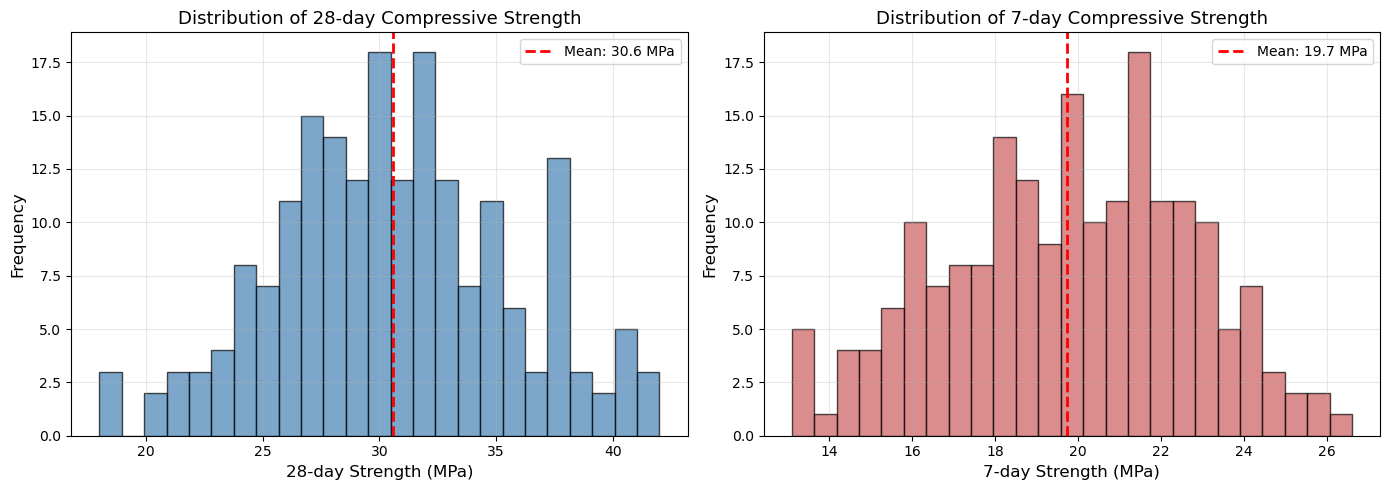

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['strength_28d_MPa'], bins=25, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('28-day Strength (MPa)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of 28-day Compressive Strength', fontsize=13)
axes[0].axvline(df_clean['strength_28d_MPa'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_clean['strength_28d_MPa'].mean():.1f} MPa")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_clean['strength_7d_MPa'], bins=25, edgecolor='black', alpha=0.7, color='indianred')
axes[1].set_xlabel('7-day Strength (MPa)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of 7-day Compressive Strength', fontsize=13)
axes[1].axvline(df_clean['strength_7d_MPa'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_clean['strength_7d_MPa'].mean():.1f} MPa")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **[DISCUSS] Look at the histograms.**
> - What is the shape of the distributions? Are they roughly symmetric or skewed?
> - What is the typical range of 28-day strength values?
> - Do the distributions look approximately normal? Why might that matter?

**Answers:**

- **Shape:** Both distributions are roughly **bell-shaped (approximately normal)** and roughly symmetric, which is what we'd expect from a well-sampled set of concrete tests with varying mix designs.

- **Typical range:** The 28-day strengths cluster between roughly **20–40 MPa**, with a mean around 30 MPa. The 7-day strengths are lower, roughly **10–25 MPa**, as expected — concrete continues to gain strength after 7 days.

- **Approximate normality:** The distributions look reasonably normal, which is good news for linear regression (which assumes normally distributed residuals). In practice, concrete strength data often follows a normal distribution when the mix design varies smoothly — this is partly due to the Central Limit Theorem, since strength is influenced by many small, independent factors (cement hydration, aggregate packing, curing variability, etc.).

- **Why it matters:** If the data were heavily skewed (e.g., a few extremely high values pulling the tail), we might need to transform it (e.g., log transform) before modeling, or use methods that are robust to skewness.

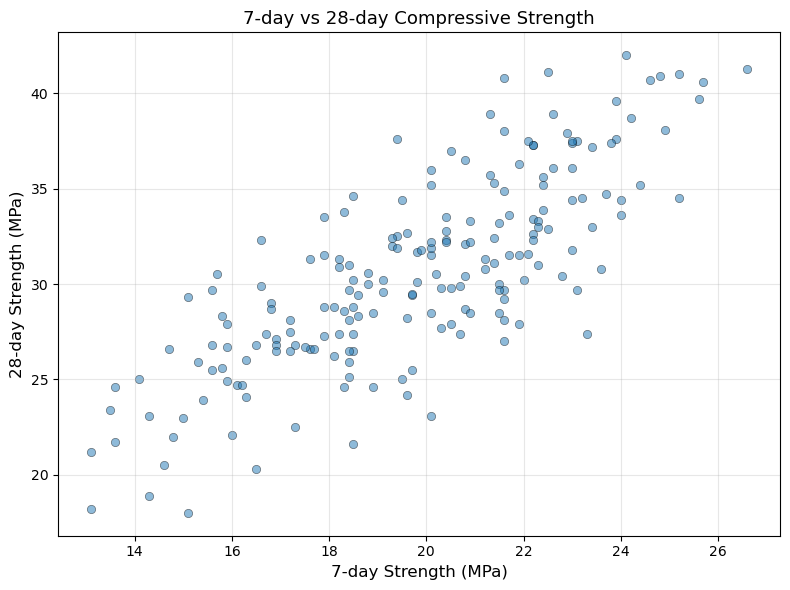

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_clean['strength_7d_MPa'], df_clean['strength_28d_MPa'], alpha=0.5, edgecolors='k', linewidth=0.5)
ax.set_xlabel('7-day Strength (MPa)', fontsize=12)
ax.set_ylabel('28-day Strength (MPa)', fontsize=12)
ax.set_title('7-day vs 28-day Compressive Strength', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **[DISCUSS] The scatter plot tells a story.**
> - Is there a clear trend? What kind of relationship does this look like — linear, curved, or no pattern?
> - Are there any outliers or unusual points?
> - Based on this plot alone, do you think we can build a useful predictive model?

**Answers:**

- **Clear positive linear trend.** As 7-day strength increases, 28-day strength increases proportionally. The relationship looks strongly linear — points form a tight elongated cloud along a diagonal line. There is no obvious curvature.

- **No dramatic outliers** remain after cleaning (we already removed the 900 MPa data entry error). The scatter is reasonably uniform across the range, though you may notice slightly more spread at higher strength values (this is common — it's called **heteroscedasticity**, and we'll check for it in the residuals later).

- **Can we build a useful model?** Yes — the tight linear pattern suggests that a simple linear regression will do a good job. The correlation is visually strong (likely r > 0.85). This makes physical sense: the same cement hydration process that gives high 7-day strength continues to produce high 28-day strength. The 28-day strength is essentially the 7-day strength plus additional hydration gains.

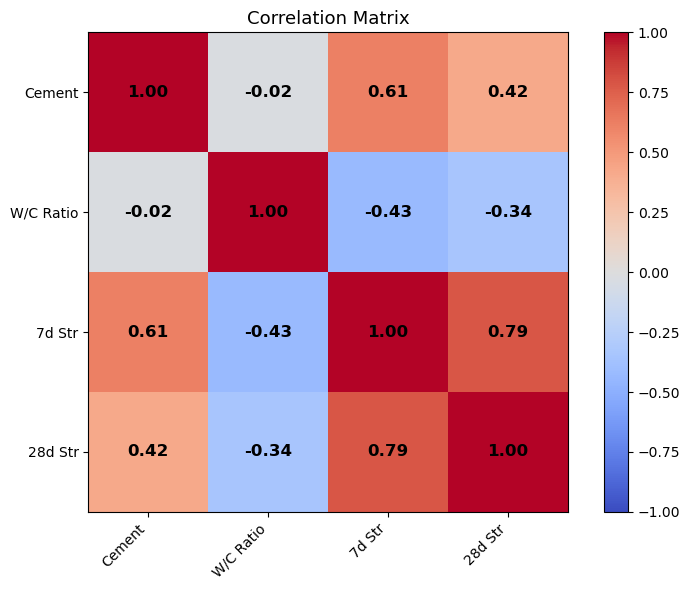

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_clean[['cement_kg_m3', 'water_cement_ratio', 'strength_7d_MPa', 'strength_28d_MPa']].corr()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(['Cement', 'W/C Ratio', '7d Str', '28d Str'], rotation=45, ha='right')
ax.set_yticklabels(['Cement', 'W/C Ratio', '7d Str', '28d Str'])
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

> **Key Insight: EDA is Detective Work**
> Before building any model, you must *see* your data. Visualizations reveal patterns, outliers, and relationships that summary statistics alone can miss.

> **[QUICK] Which feature has the strongest correlation with 28-day strength?**
> - Look at the bottom row of the correlation matrix.
> - Is it 7-day strength, cement content, or water-cement ratio?
> - Does this make physical sense?

**Answer:**

**7-day strength** has the strongest correlation with 28-day strength (r ≈ 0.90+). This is the bottom-right region of the correlation matrix — the (28d Str, 7d Str) cell should show the highest absolute value in that row.

- **Water-cement ratio** also correlates well (negatively — higher W/C means weaker concrete, following Abrams' law).
- **Cement content** shows a positive but weaker correlation.

**Does it make physical sense?** Absolutely. The 7-day strength is a *direct measurement* of the same physical process (cement hydration) that determines 28-day strength. Cement content and W/C ratio are *inputs* to the process, but they don't capture other factors like curing conditions, aggregate quality, or admixtures. The 7-day test result already integrates all of those factors — it's a "live measurement" of how this specific batch is performing, not just a design parameter.

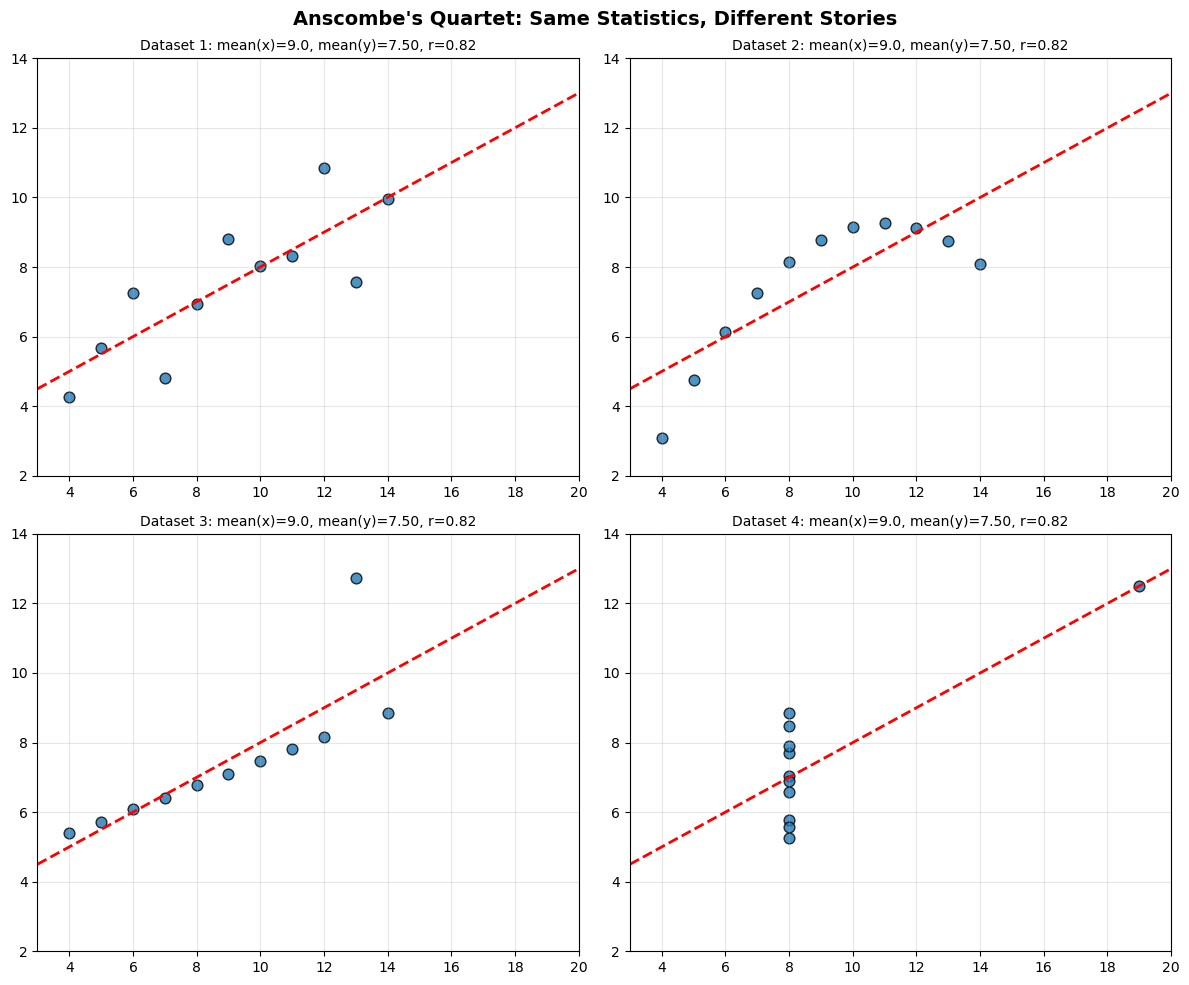

In [31]:
# Anscombe's Quartet — four datasets with IDENTICAL statistics
from typing import Any


anscombe_x = [
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8]
]
anscombe_y = [
    [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, ax in enumerate[Any](axes.flat):
    x = np.array(anscombe_x[idx])
    y = np.array(anscombe_y[idx])
    ax.scatter(x, y, s=60, edgecolors='k', alpha=0.8)
    # Fit line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(3, 20, 100)
    ax.plot(x_line, m * x_line + b, 'r--', linewidth=2)
    ax.set_title(f'Dataset {idx + 1}: mean(x)={x.mean():.1f}, mean(y)={y.mean():.2f}, r={np.corrcoef(x, y)[0,1]:.2f}', fontsize=10)
    ax.set_xlim(3, 20)
    ax.set_ylim(2, 14)
    ax.grid(True, alpha=0.3)

plt.suptitle("Anscombe's Quartet: Same Statistics, Different Stories", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

All four datasets above have **nearly identical** means, variances, correlations, and regression lines — yet they tell completely different stories. This is why we **never skip visualization**.

> **Key Insight: Correlation is Not Causation**
> A classic example from civil engineering: both *ice cream sales* and *bridge expansion joint failures* increase in summer. They are correlated — but ice cream doesn't cause bridge failures. Temperature is the **confounding variable** driving both.
>
> Always ask: is there a plausible *causal mechanism*, or just a statistical association?

---
## 4. Feature Engineering

Feature engineering is the process of creating new input variables from existing data. This is where **domain expertise** becomes a superpower.

> **Definition: Feature Engineering**
> The process of using domain knowledge to create new variables (features) that make machine learning models more effective.


In [32]:
# Feature engineering — adding domain knowledge
df_clean = df_clean.copy()
df_clean['strength_gain_rate'] = df_clean['strength_28d_MPa'] / df_clean['strength_7d_MPa']
df_clean['cement_efficiency'] = df_clean['strength_28d_MPa'] / df_clean['cement_kg_m3']

print("New features created:")
print(f"  strength_gain_rate — how much strength grows from 7 to 28 days")
print(f"  cement_efficiency — strength per kg of cement")
print(f"\nSample values:")
df_clean[['sample_id', 'strength_7d_MPa', 'strength_28d_MPa', 'strength_gain_rate', 'cement_efficiency']].head()

New features created:
  strength_gain_rate — how much strength grows from 7 to 28 days
  cement_efficiency — strength per kg of cement

Sample values:


,sample_id,strength_7d_MPa,strength_28d_MPa,strength_gain_rate,cement_efficiency
0,C001,21.2,30.8,1.452830,0.094798
1,C002,24.2,38.7,1.599174,0.098198
2,C003,23.9,37.6,1.573222,0.102229
3,C004,18.4,25.9,1.407609,0.073621
4,C005,18.1,28.8,1.591160,0.096418


> **Example: Civil Engineering**
> A data scientist might use `cement_kg_m3` and `water_cement_ratio` as separate features. But a civil engineer knows that the *interaction* between water and cement (i.e., `water_cement_ratio * cement_kg_m3` = total water content) is physically meaningful. This kind of domain-informed feature often improves model performance significantly.

> **[PRACTICE] Think of other features you could derive:**
> - What about the ratio of 7-day to 28-day strength? (already created above)
> - Could temperature or curing conditions matter? (yes, but not in our dataset)
> - What about cement type or aggregate properties?

**Answers — Feature ideas a civil engineer would think of:**

| Feature | Formula / Source | Why It Matters |
|---|---|---|
| **Total water content** | `water_cement_ratio × cement_kg_m3` | Directly governs paste porosity and thus strength (Abrams' law). More physically meaningful than W/C or cement alone. |
| **Strength gain ratio** | `strength_28d / strength_7d` | Indicates hydration kinetics. Rapid early gain (low ratio ≈ 1.2) suggests fast-setting cement; slow gain (high ratio ≈ 1.6) suggests pozzolanic mixes. |
| **Squared 7-day strength** | `strength_7d²` | Captures potential nonlinearity — the relationship between 7d and 28d strength may not be perfectly linear at extremes. |
| **Curing temperature** | (not in our dataset) | Higher temperatures accelerate early strength but can reduce ultimate strength — a well-known trade-off in concrete technology. |
| **Cement type indicator** | (not in our dataset) | OPC vs. blended cements (fly ash, slag) have very different strength gain curves. Type I/II cement gains most strength early; Type IV gains slowly. |
| **Aggregate properties** | (not in our dataset) | Maximum aggregate size, gradation, and mineralogy affect strength, especially in high-performance concrete. |

The key takeaway: **the best features come from understanding the physics of the problem**, not from blind statistical manipulation. A civil engineer who understands cement hydration can create features that a generic data scientist would miss entirely.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Raw features
X_raw = df_clean[['strength_7d_MPa', 'cement_kg_m3', 'water_cement_ratio']].values
y = df_clean['strength_28d_MPa'].values

# Engineered features (add ratio and interaction)
X_eng = df_clean[['strength_7d_MPa', 'cement_kg_m3', 'water_cement_ratio']].copy()
X_eng['wc_x_cement'] = df_clean['water_cement_ratio'] * df_clean['cement_kg_m3']
X_eng['strength_7d_sq'] = df_clean['strength_7d_MPa'] ** 2
X_eng = X_eng.values

model_raw = LinearRegression()
model_eng = LinearRegression()

scores_raw = cross_val_score(model_raw, X_raw, y, cv=5, scoring='r2')
scores_eng = cross_val_score(model_eng, X_eng, y, cv=5, scoring='r2')

print(f"Raw features    — Mean R²: {scores_raw.mean():.3f} (±{scores_raw.std():.3f})")
print(f"Engineered feat — Mean R²: {scores_eng.mean():.3f} (±{scores_eng.std():.3f})")

Raw features    — Mean R²: 0.590 (±0.118)
Engineered feat — Mean R²: 0.581 (±0.118)


> **Key Insight: Feature Engineering is Where Domain Knowledge Meets Data Science**
> A civil engineer can create features — like the water-cement interaction or strength gain rate — that a generic data scientist wouldn't think of. This is your competitive advantage.

---
## 5. Modeling

Now we build a predictive model. The golden rule:

> **Key Insight: Start Simple**
> Begin with the simplest model that could work. If linear regression gives you R² = 0.90, you may not need a neural network. <mark>Simple models are easier to explain, debug, and trust.<mark>

In [34]:
from sklearn.model_selection import train_test_split

X = df_clean[['strength_7d_MPa']].values
y = df_clean['strength_28d_MPa'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model: strength_28d = {model.coef_[0]:.2f} × strength_7d + {model.intercept_:.2f}")
print(f"Train R²: {model.score(X_train, y_train):.3f}")
print(f"Test R²:  {model.score(X_test, y_test):.3f}")

Model: strength_28d = 1.28 × strength_7d + 5.26
Train R²: 0.590
Test R²:  0.684


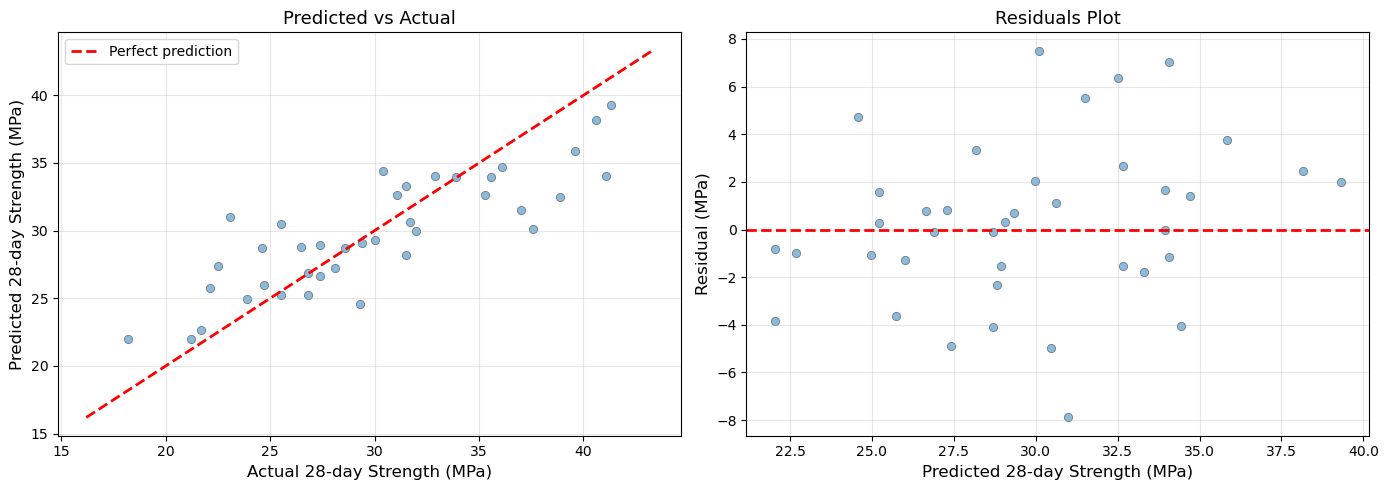

In [35]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual 28-day Strength (MPa)', fontsize=12)
axes[0].set_ylabel('Predicted 28-day Strength (MPa)', fontsize=12)
axes[0].set_title('Predicted vs Actual', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].scatter(y_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted 28-day Strength (MPa)', fontsize=12)
axes[1].set_ylabel('Residual (MPa)', fontsize=12)
axes[1].set_title('Residuals Plot', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **[DISCUSS] Look at the residuals plot.**
> - Are the errors randomly scattered? Or do you see a pattern?
> - If there's a pattern, the model is missing something. What could it be?

> **Key Insight: Start Simple**
> <mark> A simple model you understand beats a complex model you don't. Linear regression is interpretable: "For every 1 MPa increase in 7-day strength, 28-day strength increases by about X MPa."

**Answers:**

- **Predicted vs Actual plot (left):** Points cluster tightly around the red dashed "perfect prediction" line. This confirms the model is doing a good job overall — predictions are close to actual values across the full range.

- **Residuals plot (right):** The residuals should look like a random cloud centered at zero with no obvious pattern. If you see:
  - **A funnel shape** (spread increasing left-to-right) → heteroscedasticity — the model is less reliable at higher predicted values.
  - **A curve** (U-shape or arch) → the true relationship is nonlinear, and a straight line is missing something.
  - **Random scatter** → good news! The linear model is capturing the relationship well.

- **What could the model be missing?** Even if residuals look random here, remember we're using only 7-day strength as input. Adding features like cement content, W/C ratio, or curing temperature could reduce the residual scatter further. The remaining error is partly due to natural variability in concrete (no two batches are identical) and measurement noise in the testing process itself.

---
## 6. Evaluation & Communication

A model is only useful if its performance is **adequate for the application** and its results can be **communicated clearly** to decision-makers (engineers, project managers, clients).

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Model Performance in Engineering Terms ===\n")
print(f"  R² = {r2:.3f}")
print(f"    → The model explains {r2*100:.1f}% of the variation in 28-day strength.\n")
print(f"  MAE = {mae:.1f} MPa")
print(f"    → Predictions are off by about {mae:.1f} MPa on average.\n")
print(f"  RMSE = {rmse:.1f} MPa")
print(f"    → Typical prediction error is about {rmse:.1f} MPa.\n")
print(f"  Is this acceptable? It depends on the application:")
print(f"    - Quality control (pass/fail at 30 MPa): ±{mae:.1f} MPa matters near the threshold")
print(f"    - Mix design optimization: probably acceptable")
print(f"    - Structural load rating: need to consider safety factors")

=== Model Performance in Engineering Terms ===

  R² = 0.684
    → The model explains 68.4% of the variation in 28-day strength.

  MAE = 2.6 MPa
    → Predictions are off by about 2.6 MPa on average.

  RMSE = 3.4 MPa
    → Typical prediction error is about 3.4 MPa.

  Is this acceptable? It depends on the application:
    - Quality control (pass/fail at 30 MPa): ±2.6 MPa matters near the threshold
    - Mix design optimization: probably acceptable
    - Structural load rating: need to consider safety factors


> **Key Insight: Metrics Must Be Interpreted in Context**
> "95% accuracy" means nothing without knowing the stakes. An MAE of 3 MPa might be excellent for mix design but dangerous for structural load rating.

In [ ]:
# Find a borderline sample — close to the pass/fail threshold of 30 MPa
threshold = 30.0  # MPa
borderline_mask = np.abs(y_test - threshold) < 3
borderline_idx = np.where(borderline_mask)[0]

if len(borderline_idx) > 0:
    idx = borderline_idx[0]
    print(f"Sample near the pass/fail threshold ({threshold} MPa):")
    print(f"  7-day strength: {X_test[idx, 0]:.1f} MPa")
    print(f"  Actual 28-day:  {y_test[idx]:.1f} MPa")
    print(f"  Predicted 28-day: {y_pred[idx]:.1f} MPa")
    print(f"  Actual status:    {'PASS' if y_test[idx] >= threshold else 'FAIL'}")
    print(f"  Predicted status: {'PASS' if y_pred[idx] >= threshold else 'FAIL'}")
    if (y_pred[idx] >= threshold) != (y_test[idx] >= threshold):
        print(f"\n  ⚠ WRONG CALL! The model got this one wrong.")
        print(f"  What's the cost of this error?")
else:
    print("No borderline samples found in the test set near 30 MPa.")

Sample near the pass/fail threshold (30.0 MPa):
  7-day strength: 22.8 MPa
  Actual 28-day:  30.4 MPa
  Predicted 28-day: 34.4 MPa
  Actual status:    PASS
  Predicted status: PASS


> **Key Insight: The Workflow is Iterative**
> After seeing model results, you often return to earlier stages:
> - Poor R²? → Go back to EDA, look for nonlinear patterns
> - Residuals show a pattern? → Try feature engineering
> - Model fails on borderline cases? → Consider different evaluation metrics
>
> Data science is a cycle, not a conveyor belt.

<mark>---
## 7. Reflection

<mark>Let's step back and see the full picture of what we've done — and how each stage connects to the next.<mark>

### The Full Lifecycle — Revisited

| Stage | What You Do | Key Question |
|---|---|---|
| **1. Business Understanding** | Define the problem | What question am I answering? |
| **2. Data Understanding** | Inspect, profile, explore | Is my data trustworthy? |
| **3. Data Preparation** | Clean, transform, engineer features | What does the model need? |
| **4. Modeling** | Fit, predict | What's the simplest model that works? |
| **5. Evaluation** | Measure, interpret | Is this good enough for the application? |
| **6. Deployment** | Communicate, integrate | Who uses this and how? |

> **[DISCUSS] Which stage takes the most time in practice?**
> Studies consistently show that **data cleaning and preparation** consume 60–80% of a data scientist's time. The modeling step — the "sexy" part — is often the quickest.

### Key Takeaways from Today

1. **Start with a question.** The problem defines the project, not the algorithm.
2. **Trust your data — but verify.** Garbage in, garbage out.
3. **Visualize before you model.** Anscombe's Quartet proves that statistics alone can be misleading.
4. **Domain knowledge is your superpower.** Feature engineering is where civil engineers outperform generic data scientists.
5. **Start simple.** Interpretable models build trust and reveal problems early.
6. **Context determines quality.** A 3 MPa error is acceptable for some tasks and catastrophic for others.
7. **Iterate.** The lifecycle is a loop, not a straight line.

### Connection to the CE49X Course

- **Week 01**: Python foundations (self-study) + the data science lifecycle (this notebook, in-class)
- **Week 02**: Modules, packages, and data science libraries
- **Weeks 03-04**: NumPy, Pandas, Matplotlib → Stages 2-3 (data understanding, EDA, visualization)
- **Weeks 05-06**: Statistical analysis, intro to ML → Stages 4-5 (modeling, evaluation)
- **Weeks 07-08**: Naive Bayes, SVM → Advanced modeling + evaluation philosophy

Every week builds on the lifecycle you learned today.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr